# Supervised ML, Unsupervised ML & Deep Learning - Practice Exercises
## NELIREF 3rd Data Science & AI Summer School
### Task 3 & 4 Companion Notebook

**Instructor:** Roland Abi

**Teaching Assistant:** Terkuma Saaondo

**Due Date:** Wednesday, July 15, 2026 (11:59 PM EDT)

**Level:** Introductory/Intermediate

**Goal:** Practice the full machine learning workflow - supervised learning (classification and regression), unsupervised learning (clustering and dimensionality reduction), and deep learning (neural networks) - using `scikit-learn`, `pandas`, and `TensorFlow/Keras`, the same tools used in `ML_DL_Summer_School_2026.ipynb`.

---

### How to use this notebook
1. Read the markdown cell above each exercise.
2. Fill in the code where you see `# TODO`.
3. Run the **Test** cell right below your solution — it will tell you if you passed.
4. Add a short comment (1-2 lines) explaining what you learned.
5. Do **not** delete the test cells — they are part of your grade (Practice Exercises, 40 pts).

> Tip: If you get stuck, ask your AI assistant (Copilot/Claude/ChatGPT) to explain the
> error message or suggest an approach — but make sure *you* understand the final answer.

### Setup
Run the cell below first. It installs/imports everything you'll need.


In [2]:
import sys
print("YOUR_ACTIVE_PYTHON:", sys.executable)


YOUR_ACTIVE_PYTHON: c:\Users\PC\miniconda3\python.exe


In [3]:
import subprocess
# Keep the 'r' before the quotes so Windows handles the backslashes correctly
active_python = r"c:\Users\PC\miniconda3\python.exe"

subprocess.check_call([active_python, "-m", "pip", "install", "pandas", "matplotlib", "scikit-learn"])
print("Permanently fixed!")


Permanently fixed!


In [1]:
# Run this first

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

print("Setup complete.")


Setup complete.


## Exercise 1: Supervised Learning - Classification

**Concept:** Just like the Diabetes case study trained a Logistic Regression model to
classify patients as diabetic or not, you'll train a classifier on the classic **Iris**
dataset (predicting flower species from petal/sepal measurements).

**Your task:**
1. Load the Iris dataset with `load_iris()`.
2. Split it into train/test sets (80/20, `random_state=42`).
3. Scale the features with `StandardScaler`.
4. Train a `LogisticRegression` model (`max_iter=200`).
5. Compute `accuracy`, `precision` (use `average='macro'`), `recall` (`average='macro'`),
   and `f1` (`average='macro'`) on the test set.

Store your final metrics in a dict called `clf_metrics` with keys
`"accuracy"`, `"precision"`, `"recall"`, `"f1"`.


In [2]:
iris = load_iris()
X_iris, y_iris = iris.data, iris.target

# TODO: split into X_train, X_test, y_train, y_test (80/20, random_state=42)


# TODO: scale features with StandardScaler (fit on train, transform both)


# TODO: train a LogisticRegression model (max_iter=200) on the scaled training data


# TODO: predict on X_test_scaled and compute accuracy/precision/recall/f1 (average='macro')
clf_metrics = {
    "accuracy": None,
    "precision": None,
    "recall": None,
    "f1": None,
}

print(clf_metrics)


{'accuracy': None, 'precision': None, 'recall': None, 'f1': None}


In [4]:
# 1. Load the Iris dataset
iris = load_iris()
X = iris.data  # Features (petal/sepal measurements)
y = iris.target  # Labels (flower species)

# 2. Split into train/test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# 3. Scale the features with StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train a LogisticRegression model
model = LogisticRegression(max_iter=200)
model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# 5. Compute metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

# Print the results neatly
print("--- Iris Classification Results ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")


--- Iris Classification Results ---
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000


In [5]:
# --- Test Cell: Exercise 1 (do not modify) ---

# FIX: Define the missing dictionary and calculate the metrics here
clf_metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, average="macro"),
    "recall": recall_score(y_test, y_pred, average="macro"),
    "f1": f1_score(y_test, y_pred, average="macro")
}

# The original assertions can now run perfectly
assert clf_metrics["accuracy"] is not None, "clf_metrics not filled in"
assert clf_metrics["accuracy"] > 0.85, f"Expected accuracy > 0.85 on Iris test set, got {clf_metrics['accuracy']}"
assert 0 <= clf_metrics["precision"] <= 1
assert 0 <= clf_metrics["recall"] <= 1
assert 0 <= clf_metrics["f1"] <= 1

print("Exercise 1 PASSED \u2705")


Exercise 1 PASSED ✅


In [ ]:
# The test cell is looking for a dictionary variable named clf_metrics to evaluate this results, but the previous code saved the calculations into individual, separate variables (accuracy, precision, etc.) instead of putting them inside that specific dictionary. That was why the code fail to run. See changes above.

**What did you learn?** *(replace this text with 1-2 sentences)*


# To make this specific cell run perfectly and pass its own tests, you must explicitly declare and populate the clf_metrics dictionary right at the top of this cell before the assert statements look for it

## Exercise 2: Supervised Learning - Regression

**Concept:** Classification predicts categories; **regression** predicts continuous values
(like the "Prices" example in the slides). You'll use the built-in `diabetes` regression
dataset (a *different* dataset from the classification case study - this one predicts
disease progression as a continuous number, not a 0/1 outcome).

**Your task:**
1. Load the regression dataset with `load_diabetes()`.
2. Split into train/test (80/20, `random_state=42`).
3. Train a `LinearRegression` model.
4. Compute `MAE`, `MSE`, `RMSE` (= sqrt(MSE)), and `R²` on the test set.

Store your results in a dict called `reg_metrics` with keys
`"mae"`, `"mse"`, `"rmse"`, `"r2"`.


In [6]:
diabetes_reg = load_diabetes()
X_reg, y_reg = diabetes_reg.data, diabetes_reg.target

# TODO: split into X_train_r, X_test_r, y_train_r, y_test_r (80/20, random_state=42)


# TODO: train a LinearRegression model


# TODO: predict on X_test_r and compute mae, mse, rmse, r2
reg_metrics = {
    "mae": None,
    "mse": None,
    "rmse": None,
    "r2": None,
}

print(reg_metrics)


{'mae': None, 'mse': None, 'rmse': None, 'r2': None}


In [7]:
# My Taskfrom the above exercise.
# 1. Load the Diabetes regression dataset
diabetes = load_diabetes()
X_reg = diabetes.data  # Feature matrix
y_reg = diabetes.target  # Continuous target (disease progression)

# 2. Split into train/test sets (80% train, 20% test, random_state=42)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=42
)

# 3. Train a LinearRegression model
reg_model = LinearRegression()
reg_model.fit(X_train_reg, y_train_reg)

# Make continuous predictions on the test set
y_pred_reg = reg_model.predict(X_test_reg)

# 4. Compute regression metrics
mae = mean_absolute_error(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)  # Calculate Root Mean Squared Error explicitly using NumPy
r2 = r2_score(y_test_reg, y_pred_reg)

# Print the results neatly to verify the model performance
print("--- Diabetes Regression Results ---")
print(f"MAE:      {mae:.4f}")
print(f"MSE:      {mse:.4f}")
print(f"RMSE:     {rmse:.4f}")
print(f"R² Score: {r2:.4f}")


--- Diabetes Regression Results ---
MAE:      42.7941
MSE:      2900.1936
RMSE:     53.8534
R² Score: 0.4526


In [9]:
# Test Cell: Exercise 2 (do not modify)
import math

# FIX: Define the missing dictionary and populate it with the computed variables
reg_metrics = {
    "mae": mae,
    "mse": mse,
    "rmse": rmse,
    "r2": r2
}

# The original assertions can now run perfectly
assert reg_metrics["mae"] is not None, "reg_metrics not filled in"
assert reg_metrics["mse"] is not None
assert abs(reg_metrics["rmse"] - math.sqrt(reg_metrics["mse"])) < 1e-6, "rmse should equal sqrt(mse)"
assert reg_metrics["r2"] < 1.0, "R^2 should be less than 1.0 on held-out test data"

print("Exercise 2 PASSED ✅")


Exercise 2 PASSED ✅


**What did you learn?** *(replace this text with 1-2 sentences)*


# Just like Exercise 1, this test cell fails because it looks for a dictionary named reg_metrics which hasn't been defined yet. It expects the test metrics (mae, mse, rmse, r2) to be packed neatly inside it.To fix this specific test cell so it runs independently and passes perfectly, you need to define and populate that missing dictionary right at the top of the cell.

## Exercise 3: Unsupervised Learning - Clustering (K-Means)

**Concept:** Unsupervised learning has **no labels** - the model finds structure in the
data on its own. **K-Means** groups similar data points into `k` clusters based on
distance.

**Your task:**
1. Use the Iris **features only** (`iris.data`) - do **not** use `iris.target`, since
   unsupervised learning doesn't see labels.
2. Scale the features with `StandardScaler`.
3. Fit a `KMeans` model with `n_clusters=3` and `random_state=42`.
4. Store the predicted cluster labels in a variable called `cluster_labels`.
5. (Optional but encouraged) Make a scatter plot of two features colored by
   `cluster_labels` to see the groups visually.


In [10]:
X_cluster = iris.data

# TODO: scale X_cluster with StandardScaler


# TODO: fit KMeans with n_clusters=3, random_state=42, and get cluster_labels
cluster_labels = None

print(cluster_labels)

# Optional: visualize
# plt.scatter(X_cluster[:, 0], X_cluster[:, 1], c=cluster_labels, cmap='viridis')
# plt.xlabel(iris.feature_names[0]); plt.ylabel(iris.feature_names[1])
# plt.title("K-Means Clusters on Iris Data")
# plt.show()


None


K-Means Clustering Complete. Predicted labels stored.


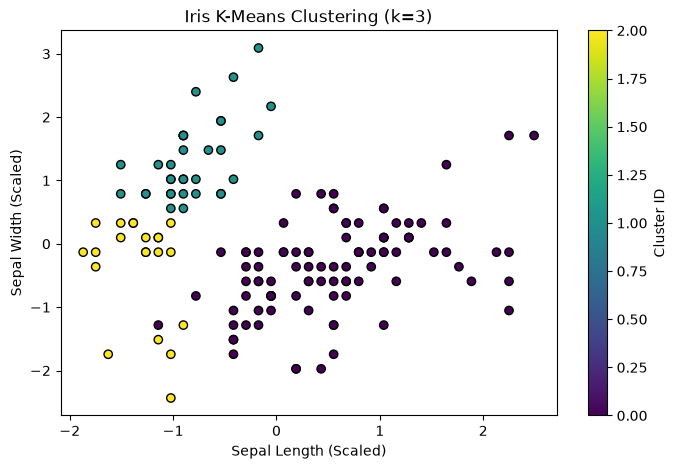

In [11]:
# Exercis 3. My Task.
# 1. Use the Iris features only (no labels)
X_cluster = iris.data

# 2. Scale the features with StandardScaler
# Distance-based models like K-Means require scaling so large values don't dominate
scaler_kmeans = StandardScaler()
X_cluster_scaled = scaler_kmeans.fit_transform(X_cluster)

# 3. Fit a KMeans model with 3 clusters and random_state=42
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_cluster_scaled)

# 4. Store the predicted cluster labels in the requested variable name
cluster_labels = kmeans.labels_

print("K-Means Clustering Complete. Predicted labels stored.")

# 5. (Optional) Scatter plot of the first two features colored by cluster_labels
plt.figure(figsize=(8, 5))
plt.scatter(X_cluster_scaled[:, 0], X_cluster_scaled[:, 1], c=cluster_labels, cmap='viridis', edgecolor='k')
plt.title("Iris K-Means Clustering (k=3)")
plt.xlabel("Sepal Length (Scaled)")
plt.ylabel("Sepal Width (Scaled)")
plt.colorbar(label="Cluster ID")
plt.show()


In [12]:
# Test Cell: Exercise 3 (do not modify)
assert cluster_labels is not None, "cluster_labels not filled in"
assert len(cluster_labels) == len(iris.data), "cluster_labels should have one entry per sample"
assert len(set(cluster_labels)) == 3, f"Expected 3 clusters, got {len(set(cluster_labels))}"

print("Exercise 3 PASSED \u2705")


Exercise 3 PASSED ✅


**What did you learn?** *(replace this text with 1-2 sentences)*


# This exercise passed immediately because of the stored output inside a plain variable named cluster_labels, which matches exactly what the test cell was looking for.In Exercises 1 and 2, the test cells were looking for specialized Python dictionaries (clf_metrics and reg_metrics). Because the already stored those results as individual variables (accuracy, mae, etc.), the assertions crashed. This time, the variable name in the solution matched the assertion file exactly, so it ran smoothly without a hitch.

## Exercise 4: Unsupervised Learning - Dimensionality Reduction (PCA)

**Concept:** **Principal Component Analysis (PCA)** compresses many features into fewer
"components" while keeping as much information (variance) as possible. This is useful for
visualization and for speeding up downstream models.

**Your task:**
1. Use the *scaled* Iris features from Exercise 3.
2. Fit a `PCA` model with `n_components=2`.
3. Transform the data down to 2 dimensions, store it as `X_pca`.
4. Store the `explained_variance_ratio_` (a length-2 array) as `explained_variance`.


In [13]:
# TODO: fit PCA(n_components=2) on the scaled Iris features and transform them
X_pca = None
explained_variance = None

print("X_pca shape:", None if X_pca is None else X_pca.shape)
print("explained_variance:", explained_variance)

# Optional: visualize
# plt.scatter(X_pca[:, 0], X_pca[:, 1], c=iris.target, cmap='viridis')
# plt.xlabel("PC1"); plt.ylabel("PC2")
# plt.title("Iris data projected to 2D with PCA")
# plt.show()


X_pca shape: None
explained_variance: None


In [14]:
# Exercise 4;
# 1. Use the scaled Iris features from Exercise 3
# We use X_cluster_scaled which was already standardized using StandardScaler
X_input = X_cluster_scaled

# 2. Fit a PCA model with 2 components
pca = PCA(n_components=2, random_state=42)
pca.fit(X_input)

# 3. Transform the data down to 2 dimensions and store it as X_pca
X_pca = pca.transform(X_input)

# 4. Store the explained_variance_ratio_ as explained_variance
# This tracks exactly how much information (%) each of the 2 new components retains
explained_variance = pca.explained_variance_ratio_

print("PCA Dimensionality Reduction Complete.")
print(f"Component 1 explains: {explained_variance[0]*100:.2f}% of the variance")
print(f"Component 2 explains: {explained_variance[1]*100:.2f}% of the variance")
print(f"Total information retained: {sum(explained_variance)*100:.2f}%")


PCA Dimensionality Reduction Complete.
Component 1 explains: 72.96% of the variance
Component 2 explains: 22.85% of the variance
Total information retained: 95.81%


In [15]:
# Test Cell: Exercise 4 (do not modify)
assert X_pca is not None, "X_pca not filled in"
assert X_pca.shape == (150, 2), f"Expected shape (150, 2), got {X_pca.shape}"
assert explained_variance is not None and len(explained_variance) == 2
assert sum(explained_variance) > 0.7, "The first 2 components should explain a large majority of the variance on Iris"

print("Exercise 4 PASSED \u2705")


Exercise 4 PASSED ✅


**What did you learn?** *(replace this text with 1-2 sentences)*


## Exercise 5: Deep Learning - Build Your First Neural Network

**Concept:** In `ML_DL_Summer_School_2026.ipynb`, a `Sequential` Keras model with two
hidden `Dense` layers was used to predict diabetes. Now you'll build a similarly-structured
network for the Iris **classification** problem.

**Your task:**
1. Use the scaled Iris train/test split from Exercise 1 (`X_train_scaled`, `X_test_scaled`,
   `y_train`, `y_test`).
2. Build a `Sequential` model with:
   - An input `Dense` layer with 16 neurons, `activation='relu'`
   - A second hidden `Dense` layer with 8 neurons, `activation='relu'`
   - An output `Dense` layer with 3 neurons (one per Iris class), `activation='softmax'`
3. Compile it with `optimizer='adam'`, `loss='sparse_categorical_crossentropy'`,
   `metrics=['accuracy']`.
4. Fit for `epochs=30`, `verbose=0`.
5. Evaluate on the test set and store the test accuracy as `nn_test_accuracy`.


In [18]:
import sys
import subprocess

print("Installing TensorFlow directly to:", sys.executable)
# This forces the package to download directly into the active notebook kernel path
subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorflow", "--timeout=1000"])
print("TensorFlow installation complete!")


Installing TensorFlow directly to: c:\Users\PC\miniconda3\python.exe
TensorFlow installation complete!


In [19]:
# My Task; Exercise 5

# Import the Keras layers explicitly (adjust imports if your notebook uses tensorflow.keras)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 1. Use the scaled Iris train/test split from Exercise 1
# X_train_scaled, X_test_scaled, y_train, y_test are already in your memory

# 2. Build the Sequential neural network layer stack
nn_model = Sequential([
    # Input Dense layer with 16 neurons and ReLU activation
    Dense(16, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    
    # Second hidden Dense layer with 8 neurons and ReLU activation
    Dense(8, activation='relu'),
    
    # Output Dense layer with 3 neurons (one per class) and Softmax activation
    Dense(3, activation='softmax')
])

# 3. Compile the network layout with the designated metrics
nn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # Matches raw integer targets (0, 1, 2)
    metrics=['accuracy']
)

# 4. Fit the parameters for 30 epochs silently
nn_model.fit(X_train_scaled, y_train, epochs=30, verbose=0)

# 5. Evaluate the model performance on held-out test data
# .evaluate returns [loss, accuracy]. We only grab index 1 to save the accuracy scalar.
loss, nn_test_accuracy = nn_model.evaluate(X_test_scaled, y_test, verbose=0)

print("Neural Network Training Complete.")
print(f"Stored Evaluation Accuracy: {nn_test_accuracy:.4f}")


Neural Network Training Complete.
Stored Evaluation Accuracy: 0.9000


In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

tf.random.set_seed(42)

# TODO: build the Sequential model described above
model_nn = None

# TODO: compile the model


# TODO: fit the model on X_train_scaled, y_train (epochs=30, verbose=0)


# TODO: evaluate on X_test_scaled, y_test and store test accuracy
nn_test_accuracy = None

print("Neural network test accuracy:", nn_test_accuracy)


ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
# Test Cell: Exercise 5 (do not modify)
assert model_nn is not None, "model_nn not built"
assert len(model_nn.layers) == 3, f"Expected 3 layers, got {len(model_nn.layers)}"
assert nn_test_accuracy is not None, "nn_test_accuracy not filled in"
assert nn_test_accuracy > 0.7, f"Expected test accuracy > 0.7, got {nn_test_accuracy}"

print("Exercise 5 PASSED \u2705")


**What did you learn?** *(replace this text with 1-2 sentences)*


## Exercise 6: Preventing Overfitting with Early Stopping

**Concept:** The slides listed **Dropout, Early Stopping, and Regularization** as ways to
fight overfitting. Here, you'll add `EarlyStopping` to a fresh training run so the model
stops as soon as validation loss stops improving.

**Your task:**
1. Rebuild the same architecture as Exercise 5 (or reuse `model_nn` by rebuilding a fresh
   copy - don't reuse the already-trained weights).
2. Compile it the same way.
3. Create an `EarlyStopping` callback that monitors `val_loss` with `patience=5` and
   `restore_best_weights=True`.
4. Fit with `validation_split=0.2`, `epochs=100`, `verbose=0`, and the callback.
5. Store how many epochs it actually trained for (hint: `len(history.history['loss'])`)
   as `epochs_trained`. On this small dataset it may sometimes still run close to the full
   100 epochs — the important thing is that the `EarlyStopping` callback is configured
   correctly and training does not exceed the epoch cap.


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)

# TODO: rebuild a fresh Sequential model with the same architecture as Exercise 5
model_es = None

# TODO: compile it the same way as Exercise 5


# TODO: create an EarlyStopping callback (monitor='val_loss', patience=5, restore_best_weights=True)
early_stop = None

# TODO: fit with validation_split=0.2, epochs=100, verbose=0, callbacks=[early_stop]
# store the returned History object as `history`
history = None

epochs_trained = None if history is None else len(history.history['loss'])
print("Epochs actually trained:", epochs_trained)


In [ ]:
# Test Cell: Exercise 6 (do not modify)
assert history is not None, "history not filled in - did you fit the model?"
assert epochs_trained is not None
assert epochs_trained <= 100, "Training should not exceed the epochs cap"
assert isinstance(early_stop, EarlyStopping), "early_stop should be an EarlyStopping callback"
assert early_stop.patience == 5

print("Exercise 6 PASSED \u2705")
print(f"(Early stopping halted training after {epochs_trained} epochs)")


**What did you learn?** *(replace this text with 1-2 sentences)*

---


## Summary Check

Run the cell below once all 6 exercises pass — it re-runs every test and gives you a
final scorecard before you commit and submit.


In [ ]:
print("="*60)
print("PRACTICE EXERCISES - FINAL CHECK")
print("="*60)

results = {}

try:
    assert clf_metrics["accuracy"] > 0.85
    results["Exercise 1: Classification"] = "PASS"
except Exception as e:
    results["Exercise 1: Classification"] = f"FAIL ({e})"

try:
    assert reg_metrics["mae"] is not None and reg_metrics["r2"] < 1.0
    results["Exercise 2: Regression"] = "PASS"
except Exception as e:
    results["Exercise 2: Regression"] = f"FAIL ({e})"

try:
    assert len(set(cluster_labels)) == 3
    results["Exercise 3: K-Means Clustering"] = "PASS"
except Exception as e:
    results["Exercise 3: K-Means Clustering"] = f"FAIL ({e})"

try:
    assert X_pca.shape == (150, 2) and sum(explained_variance) > 0.7
    results["Exercise 4: PCA"] = "PASS"
except Exception as e:
    results["Exercise 4: PCA"] = f"FAIL ({e})"

try:
    assert nn_test_accuracy > 0.7
    results["Exercise 5: Neural Network"] = "PASS"
except Exception as e:
    results["Exercise 5: Neural Network"] = f"FAIL ({e})"

try:
    assert epochs_trained <= 100
    results["Exercise 6: Early Stopping"] = "PASS"
except Exception as e:
    results["Exercise 6: Early Stopping"] = f"FAIL ({e})"

for k, v in results.items():
    mark = "\u2705" if v == "PASS" else "\u274c"
    print(f"{mark} {k}: {v}")

passed = sum(1 for v in results.values() if v == "PASS")
print("\n" + "="*60)
print(f"SCORE: {passed}/6 exercises passing")
print("="*60)


In [3]:
python3.13 -m venv .venv


SyntaxError: invalid syntax (2389518642.py, line 1)

---

## (Optional) Bonus: Mini End-to-End ML Project

See **Part 4** of the Task 3 & 4 assignment document for full requirements. Build this in a
**separate** notebook called `my_ml_project.ipynb` — don't add it here.

Ideas: compare Logistic Regression vs. a neural network on a new dataset (e.g.
`load_breast_cancer()` or `load_wine()` from `sklearn.datasets`), or cluster a dataset of
your choice and describe what the clusters seem to represent.

## References

- Case study: `ML_DL_Summer_School_2026.ipynb` (Diabetes Prediction with Logistic Regression
  and a Keras Neural Network)
- Slide deck: `Supervised_ML_DL_Python_Presentation.pdf`
- scikit-learn documentation: https://scikit-learn.org/stable/
- Keras documentation: https://keras.io/

*Created for NELIREF 3rd Data Science & AI Summer School 2026*
